---
title: "Evaluation and Operational Contracts"
draft: true
categories: [agents, workflows, langgraph, ai-engineering, search, retrieval, memory, evaluation]
---

A change plan can sound convincing while retrieving the wrong files, missing the relevant test, or relying on stale memory. This chapter evaluates retrieval, impact analysis, verification, memory, graph behavior, and artifact completeness as separate engineering claims.


## Layered evaluation

The fixture suite contains worked, validation, and challenge scenarios across behavior, configuration, and seeded regression questions. Each has expected source records, symbols, and related tests, so retrieval and impact claims are scored before the final plan is read.


In [1]:
from IPython.display import Markdown, display
from change_planner.evaluation import compare_variants, evaluate_suite, retrieval_scorecard


retrieval = retrieval_scorecard()
display(Markdown(
    "| Method | Precision@k | Recall@k | MRR | nDCG@k | Est. latency | Index cost |\n"
    "|---|---:|---:|---:|---:|---:|---:|\n"
    + "\n".join(
        f"| {row['method']} | {row['precision_at_k']:.2f} | {row['recall_at_k']:.2f} | "
        f"{row['mrr']:.2f} | {row['ndcg_at_k']:.2f} | {row['estimated_latency_ms']:.0f} ms | "
        f"{row['index_cost_units']} |"
        for row in retrieval
    )
))

variants = compare_variants()
rows = "\n".join(
    f"| {row['variant']} | {row['evidence_recall']:.2f} | {row['test_recall']:.2f} | "
    f"{row['review_compliance']:.2f} | {row['resume_correctness']:.2f} | {row['latency_ms']:.0f} |"
    for row in variants
)
display(Markdown(
    "| Variant | Evidence | Tests | Review | Resume | Latency ms |\n"
    "|---|---:|---:|---:|---:|---:|\n" + rows
))

report = evaluate_suite()
impact_rows = "\n".join(
    f"| {row.case_id} | {row.affected_file_recall:.2f} | "
    f"{row.affected_symbol_recall:.2f} | {row.related_test_recall:.2f} |"
    for row in report.rows
)
display(Markdown(
    "| Case | Affected files | Affected symbols | Related tests |\n"
    "|---|---:|---:|---:|\n" + impact_rows
))
print("means:", report.means)
print("tiers:", {tier: values["evidence_recall"] for tier, values in report.tier_means.items()})
assert len(retrieval) == 5
assert all(0.0 <= row["ndcg_at_k"] <= 1.0 for row in retrieval)
assert len(report.rows) == 4
assert all(row.affected_file_recall == 1.0 for row in report.rows)
assert all(row.related_test_recall == 1.0 for row in report.rows)



| Method | Precision@k | Recall@k | MRR | nDCG@k | Est. latency | Index cost |
|---|---:|---:|---:|---:|---:|---:|
| lexical | 0.50 | 0.92 | 0.88 | 0.85 | 9 ms | 2057 |
| dense | 0.38 | 0.67 | 0.88 | 0.65 | 18 ms | 4114 |
| structural | 0.29 | 0.50 | 0.50 | 0.48 | 9 ms | 2057 |
| hybrid | 0.50 | 0.92 | 1.00 | 0.89 | 36 ms | 8228 |

| Variant | Evidence | Tests | Review | Resume | Latency ms |
|---|---:|---:|---:|---:|---:|
| full | 1.00 | 1.00 | 1.00 | 1.00 | 25 |
| sequential | 1.00 | 1.00 | 1.00 | 1.00 | 82 |
| no_review | 1.00 | 1.00 | 0.00 | 1.00 | 25 |
| no_checkpointing | 1.00 | 1.00 | 1.00 | 0.00 | 25 |
| no_memory | 1.00 | 1.00 | 1.00 | 1.00 | 25 |

| Case | Affected files | Affected symbols | Related tests |
|---|---:|---:|---:|
| dry-run-01 | 1.00 | 1.00 | 1.00 |
| retry-01 | 1.00 | 1.00 | 1.00 |
| dry-run-02 | 1.00 | 1.00 | 1.00 |
| retry-02 | 1.00 | 1.00 | 1.00 |

means: {'evidence_recall': 1.0, 'test_recall': 1.0, 'symbol_recall': 1.0, 'affected_file_recall': 1.0, 'affected_symbol_recall': 1.0, 'related_test_recall': 1.0, 'citation_completeness': 1.0, 'bounded_termination': 1.0, 'review_compliance': 1.0, 'resume_correctness': 1.0, 'latency_ms': 25.0, 'cost_units': 12.5}
tiers: {'worked': 1.0, 'validation': 1.0, 'challenge': 1.0}


Retrieval and workflow metrics answer different questions. A sequential graph can preserve evidence while increasing latency; removing review can leave retrieval unchanged while violating a governance contract. The scorecard reports both instead of hiding the tradeoff in a single agent-quality number.

## Regression and memory checks

The seeded retry scenario tests whether the agent recovers the duplicate-write history and related test. Repeated investigations then test whether memory helps without allowing stale or unsupported records to masquerade as current evidence.


In [2]:
from IPython.display import Markdown, display
from change_planner.evaluation import memory_scorecard

rows = memory_scorecard()
display(Markdown(
    "| Memory scenario | Hits | Invalidated | Conflict candidates |\n"
    "|---|---:|---:|---:|\n"
    + "\n".join(
        f"| {row['scenario']} | {row['hits']} | {row['invalidated']} | {row['conflicts']} |"
        for row in rows
    )
))
by_scenario = {row["scenario"]: row for row in rows}
print("memory scorecard:", by_scenario)
assert by_scenario["valid_memory"]["hits"] >= 1
assert by_scenario["irrelevant_memory"]["hits"] == 0
assert by_scenario["conflicting_memory"]["conflicts"] >= 1
assert by_scenario["stale_memory"]["invalidated"] >= 1


| Memory scenario | Hits | Invalidated | Conflict candidates |
|---|---:|---:|---:|
| no_memory | 0 | 0 | 0 |
| valid_memory | 1 | 0 | 0 |
| irrelevant_memory | 0 | 0 | 0 |
| conflicting_memory | 1 | 0 | 3 |
| stale_memory | 0 | 1 | 0 |

memory scorecard: {'no_memory': {'scenario': 'no_memory', 'hits': 0, 'invalidated': 0, 'conflicts': 0}, 'valid_memory': {'scenario': 'valid_memory', 'hits': 1, 'invalidated': 0, 'conflicts': 0}, 'irrelevant_memory': {'scenario': 'irrelevant_memory', 'hits': 0, 'invalidated': 0, 'conflicts': 0}, 'conflicting_memory': {'scenario': 'conflicting_memory', 'hits': 1, 'invalidated': 0, 'conflicts': 3}, 'stale_memory': {'scenario': 'stale_memory', 'hits': 0, 'invalidated': 1, 'conflicts': 0}}


## Contract ablations

The graph variant must be compared with a direct retrieval path and a staged planner. The following figure makes the removed contracts visible; the values are workflow scores across the frozen fixture cases, not a claim that the agent proved production safety.


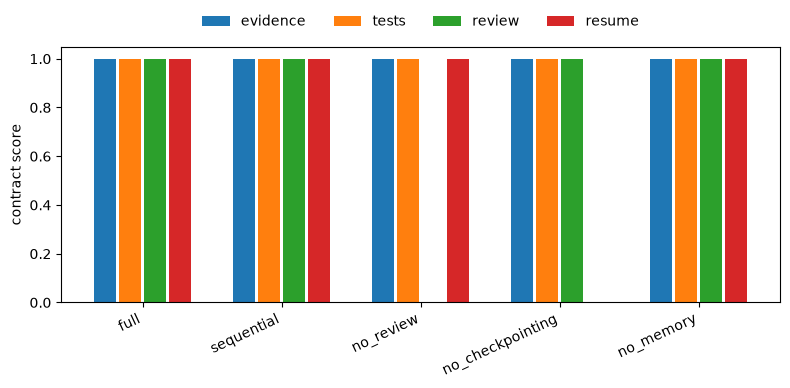

In [3]:
#| label: fig-change-planner-ablation-scorecard
#| fig-cap: "**Change Planner ablations by layer.** Retrieval and workflow contracts remain separate."
#| code-fold: true
import matplotlib.pyplot as plt

variants = [row["variant"] for row in compare_variants()]
reports = {row["variant"]: row for row in compare_variants()}
metrics = [("evidence_recall", "evidence"), ("test_recall", "tests"), ("review_compliance", "review"), ("resume_correctness", "resume")]
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(variants))
for offset, (metric, label) in enumerate(metrics):
    ax.bar([i + (offset - 1.5) * 0.18 for i in x], [reports[name][metric] for name in variants], width=0.16, label=label)
ax.set_xticks(list(x), variants, rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("contract score")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)
fig.tight_layout()
plt.show()


The acceptance gate is not “the model sounded right.” It is that retrieval is measured, evidence remains revision-consistent, seeded regressions are localized, memory has freshness behavior, graph routes terminate, review changes state, and the exported plan preserves unknowns. Chapter 09 assembles those contracts into the capstone.
